# B+ → π+ π+ π−: magnitude/phase QMI / isobar closure without CP

This notebook is the polar counterpart of the Cartesian notebook 23. It asks:

> Can a one-dimensional QMI S-wave fitted directly in magnitude and phase recover an isobaric S-wave truth?

The toy, isobaric truth model, QMI knot positions, normalization convention, higher-wave
components and fit strategy are kept the same as in the Cartesian baseline. Only the
QMI knot parameterization changes:

- each knot has a fitted magnitude `S_QMI.magnitude[i]`;
- each knot has a fitted phase `S_QMI.phase[i]`;
- magnitude and phase are interpolated independently in (s=m^2);
- every magnitude starts at `1.0`;
- every phase starts at `0.0`;
- the global QMI coefficient is fixed to (1+0i).


In [1]:
import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dataclasses import dataclass

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    Parameter,
    QMI,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
    enable_x64,
    generate_signal_toy,
)

enable_x64()

SEED = 20260905
N_EVENTS = 250_000
NORMALIZATION_RESOLUTION = 1500
QMI_INTERPOLATION = "natural"
TOY_METHOD = "accept-reject"

channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))
M_PI = float(channel.daughter_masses[0])

print("Toy size:", N_EVENTS)
print("Normalization resolution:", NORMALIZATION_RESOLUTION)
print("QMI interpolation:", QMI_INTERPOLATION)
print("Toy method:", TOY_METHOD)


Toy size: 250000
Normalization resolution: 1500
QMI interpolation: natural
Toy method: accept-reject


## Isobaric truth

We keep the CP-averaged Cartesian coefficients from the previous example and
drop all `dx/dy` terms. Thus each component has a single coefficient

\[
c_j = x_j + i y_j.
\]

The $\rho(770)$ is the amplitude reference.


In [2]:
TRUTH_COEFFICIENTS = {
    "rho770":    dict(x= 1.000, y= 0.000),
    "omega782":  dict(x= 0.091, y=-0.007),
    "f2_1270":   dict(x= 0.291, y= 0.204),
    "rho1450":   dict(x=-0.223, y= 0.191),
    "rho3_1690": dict(x= 0.073, y=-0.045),
    "sigma":     dict(x=-0.485, y= 0.284),
}

def truth_coefficient(name):
    p = TRUTH_COEFFICIENTS[name]
    return RealImag(p["x"], p["y"])


In [3]:
@dataclass(frozen=True)
class PaperSigmaPole:
    # LHCb Eq. (16): A_sigma(m) = 1 / (s_sigma - m^2)
    def __call__(self, mass, context):
        m = jnp.asarray(mass)
        pole = jnp.asarray(context.pole_mass) - 1j * jnp.asarray(context.pole_width)
        s_sigma = pole**2
        return 1.0 / (s_sigma - m**2)


def generator_components():
    return [
        Resonance(
            "rho770", (0, 2), truth_coefficient("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), truth_coefficient("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            lineshape=RelativisticBreitWigner(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), truth_coefficient("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), truth_coefficient("rho1450"),
            mass=1.465, width=0.400, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), truth_coefficient("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "sigma", (0, 2), truth_coefficient("sigma"),
            mass=0.563, width=0.350, spin=0,
            lineshape=PaperSigmaPole(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


generator = DecayModel(
    channel,
    generator_components(),
    normalize_components=True,
    normalization_method="gauss-legendre",
    #normalization_resolution=NORMALIZATION_RESOLUTION,
    #normalization_pair=(0, 2),
)

print("Generator normalization points:", generator.normalization_sample.size)


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
Generator normalization points: 2080469


## Generate the isobaric toy

The toy is generated with the exact accept-reject reference sampler. The
candidate pools are evaluated directly in Dalitz invariants; four-momenta are
not retained because this closure uses only $s_{12}$, $s_{13}$ and $s_{23}$.


In [4]:
toy = generate_signal_toy(
    generator,
    N_EVENTS,
    seed=SEED,
    method=TOY_METHOD,
    include_momenta=False,
)

print("Generated events:", toy.size)
print("Toy method:", TOY_METHOD)
print("weights:", np.unique(np.asarray(toy.weights)))


Generated events: 250000
Toy method: accept-reject
weights: [1.]


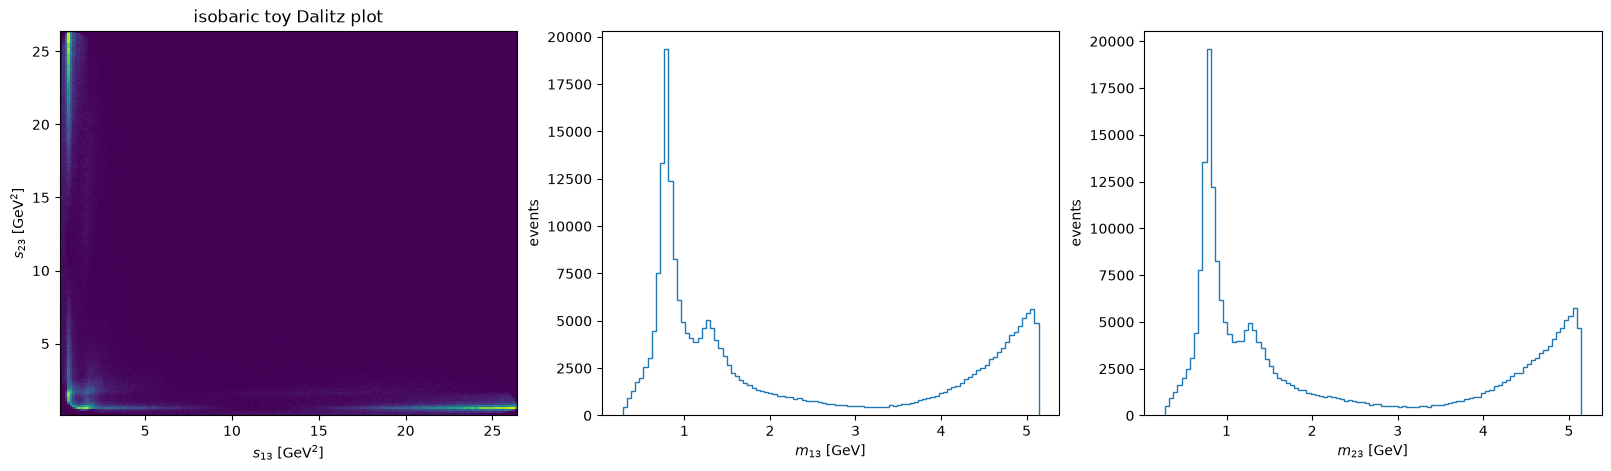

In [5]:
# Toy Dalitz plot and invariant-mass projections before any fit.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

axes[0].hist2d(
    np.asarray(toy.s13),
    np.asarray(toy.s23),
    bins=180,
)
axes[0].set_xlabel(r"$s_{13}$ [GeV$^2$]")
axes[0].set_ylabel(r"$s_{23}$ [GeV$^2$]")
axes[0].set_title("isobaric toy Dalitz plot")

for ax, values, label in [
    (axes[1], np.sqrt(np.asarray(toy.s13)), r"$m_{13}$"),
    (axes[2], np.sqrt(np.asarray(toy.s23)), r"$m_{23}$"),
]:
    ax.hist(values, bins=100, histtype="step")
    ax.set_xlabel(label + " [GeV]")
    ax.set_ylabel("events")

plt.show()


## Build truth-informed magnitude/phase QMI knots

The physical scalar amplitude that the QMI must reproduce is not the bare
(sigma) lineshape. It includes the generated complex coefficient and the
component normalization convention used by the `DecayModel`:

[
A_S^{\rm truth}(m)
=
c_\sigma\,N_\sigma\,A_\sigma(m).
]

For this polar test we evaluate that physical amplitude at the QMI knots and
retain its magnitude and an unwrapped phase. These truth values are used only
for diagnostics and the representation-only comparison; they are **not** used
as the fit starting point.

The first and last knots are placed at the exact kinematic boundaries of the
(pi^+pi^-) pair.


In [6]:
def component_by_name(model, name):
    for component in model.amplitude_model.components:
        if component.name == name:
            return component
    raise KeyError(name)


def scalar_truth_single_pair(masses):
    comp = component_by_name(generator, "sigma")
    coefficient = complex(np.asarray(comp.coefficient.value({})))
    scale = float(np.asarray(generator._component_scale(comp, {})))
    lineshape = comp.function.lineshape
    context = comp.function.context.resolve({})
    return coefficient * scale * np.asarray(
        lineshape(jnp.asarray(masses), context)
    )


PAIR_THRESHOLD = channel.daughter_masses[0] + channel.daughter_masses[2]
PAIR_MAXIMUM = channel.parent_mass - channel.daughter_masses[1]

QMI_KNOTS = (
    float(PAIR_THRESHOLD),
    0.400, 0.510, 0.630, 0.700, 0.770, 0.840, 0.900,
    0.990, 1.110, 1.210, 1.300, 1.400, 1.560, 1.740, 2.000,
    2.500, 3.000, 3.500,
    float(PAIR_MAXIMUM),
)

truth_knot_amplitudes = scalar_truth_single_pair(np.asarray(QMI_KNOTS))
truth_knot_real = np.real(truth_knot_amplitudes)
truth_knot_imaginary = np.imag(truth_knot_amplitudes)
truth_knot_magnitudes = np.abs(truth_knot_amplitudes)
truth_knot_phases = np.unwrap(np.angle(truth_knot_amplitudes))

print("QMI knots:", len(QMI_KNOTS))
print("physical range:", QMI_KNOTS[0], "to", QMI_KNOTS[-1], "GeV")
print()
print(
    f"{'m [GeV]':>9s} {'Re A_truth':>12s} {'Im A_truth':>12s} "
    f"{'|A_truth|':>12s} {'phase [rad]':>14s}"
)
for mass, real, imaginary, magnitude, phase in zip(
    QMI_KNOTS,
    truth_knot_real,
    truth_knot_imaginary,
    truth_knot_magnitudes,
    truth_knot_phases,
):
    print(
        f"{mass:9.4f} {real:12.6f} {imaginary:12.6f} "
        f"{magnitude:12.6f} {phase:14.6f}"
    )


QMI knots: 20
physical range: 0.27914078000000003 to 5.139839609999999 GeV

  m [GeV]   Re A_truth   Im A_truth    |A_truth|    phase [rad]
   0.2791    -0.063079    -0.059180     0.086494      -2.388076
   0.4000    -0.051987    -0.073287     0.089854      -2.187776
   0.5100    -0.031735    -0.083119     0.088972      -1.935516
   0.6300    -0.004429    -0.080109     0.080232      -1.626025
   0.7000     0.008186    -0.071696     0.072161      -1.457106
   0.7700     0.016375    -0.061279     0.063429      -1.309673
   0.8400     0.020645    -0.051059     0.055075      -1.186568
   0.9000     0.022094    -0.043327     0.048635      -1.099237
   0.9900     0.022032    -0.033915     0.040443      -0.994694
   1.1100     0.020089    -0.024941     0.032025      -0.892718
   1.2100     0.018031    -0.019744     0.026739      -0.830715
   1.3000     0.016220    -0.016285     0.022984      -0.787400
   1.4000     0.014386    -0.013385     0.019650      -0.749358
   1.5600     0.011918    -0

### Representation-only check

Before fitting anything, construct a numerical polar QMI directly from the
truth values at the knots. This isolates the interpolation convention from the
likelihood and minimizer.

For `linear` interpolation, magnitude and phase are interpolated independently
in (s=m^2):

[
|A(s)|=(1-t)|A_i|+t|A_{i+1}|,
qquad
\phi(s)=(1-t)\phi_i+t\phi_{i+1}.
]

These truth knot values are **not** used as the fit starting point.


representation-only relative complex RMS = 1.094176e-03


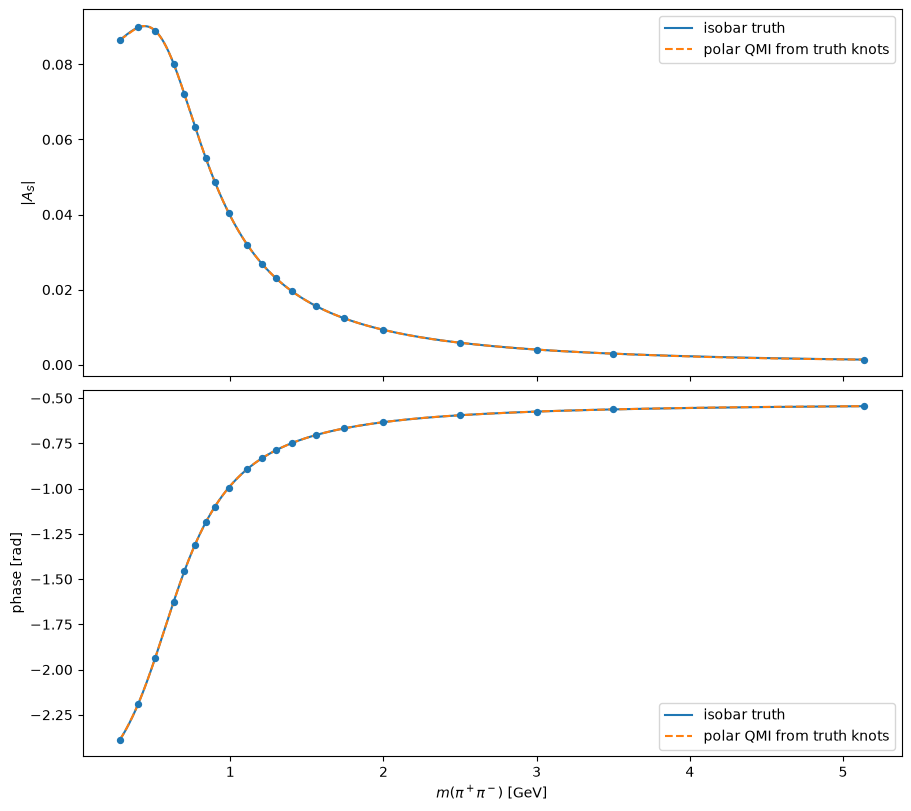

In [7]:
truth_seed_qmi = QMI(
    knots=QMI_KNOTS,
    magnitudes=tuple(float(value) for value in truth_knot_magnitudes),
    phases=tuple(float(value) for value in truth_knot_phases),
    interpolation=QMI_INTERPOLATION,
)

qmi_context = component_by_name(generator, "sigma").function.context.resolve({})

mass_scan = np.linspace(QMI_KNOTS[0], QMI_KNOTS[-1], 3000)
truth_scan = scalar_truth_single_pair(mass_scan)
seed_scan = np.asarray(
    truth_seed_qmi(jnp.asarray(mass_scan), qmi_context)
)

relative_rms = np.sqrt(
    np.mean(np.abs(seed_scan - truth_scan)**2)
    / np.mean(np.abs(truth_scan)**2)
)

print(f"representation-only relative complex RMS = {relative_rms:.6e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, constrained_layout=True)

axes[0].plot(mass_scan, np.abs(truth_scan), label="isobar truth")
axes[0].plot(mass_scan, np.abs(seed_scan), "--", label="polar QMI from truth knots")
axes[0].scatter(QMI_KNOTS, truth_knot_magnitudes, s=18, zorder=3)
axes[0].set_ylabel(r"$|A_S|$")
axes[0].legend()

axes[1].plot(mass_scan, np.unwrap(np.angle(truth_scan)), label="isobar truth")
axes[1].plot(
    mass_scan,
    np.unwrap(np.angle(seed_scan)),
    "--",
    label="polar QMI from truth knots",
)
axes[1].scatter(QMI_KNOTS, truth_knot_phases, s=18, zorder=3)
axes[1].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
axes[1].set_ylabel("phase [rad]")
axes[1].legend()

plt.show()


## Fit model

All polar QMI knot parameters are free. The global QMI coefficient is fixed to
(1+0i), so the knot magnitudes and phases themselves carry the physical
S-wave amplitude.

The fit deliberately starts **away from the truth**:

- every QMI magnitude starts at `1.0`;
- every QMI phase starts at `0.0`;
- higher-wave coefficients start at their generated values and remain free,
  except for the fixed (
ho(770)) reference.

Magnitudes are constrained to be non-negative. Phases are given a wide
(pm4pi) range to prevent numerically irrelevant runaway phase branches
without forcing the fit close to the truth.


In [8]:
def qmi_parameters():
    magnitudes = []
    phases = []
    for i in range(len(QMI_KNOTS)):
        magnitudes.append(
            Parameter.dynamics(
                f"S_QMI.magnitude[{i}]",
                1.0,
                owner="S_QMI",
                bounds=(0.0, 10.0),
                step=0.01,
            )
        )
        phases.append(
            Parameter.dynamics(
                f"S_QMI.phase[{i}]",
                0.0,
                owner="S_QMI",
                bounds=(-4.0 * np.pi, 4.0 * np.pi),
                step=0.01,
            )
        )
    return tuple(magnitudes), tuple(phases)


qmi_magnitudes, qmi_phases = qmi_parameters()
print("QMI fit start: all magnitudes = 1.0, all phases = 0.0")

qmi = QMI(
    knots=QMI_KNOTS,
    magnitudes=qmi_magnitudes,
    phases=qmi_phases,
    interpolation=QMI_INTERPOLATION,
)


def floating_coefficient(name):
    truth = TRUTH_COEFFICIENTS[name]
    reference = name == "rho770"
    x = Parameter.coefficient(
        f"{name}.x",
        truth["x"],
        owner=name,
        fixed=reference,
        step=0.01,
    )
    y = Parameter.coefficient(
        f"{name}.y",
        truth["y"],
        owner=name,
        fixed=reference,
        step=0.01,
    )
    return RealImag(x, y)


def fit_components():
    return [
        Resonance(
            "rho770", (0, 2), floating_coefficient("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), floating_coefficient("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), floating_coefficient("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), floating_coefficient("rho1450"),
            mass=1.465, width=0.400, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), floating_coefficient("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "S_QMI", (0, 2), RealImag(1.0, 0.0),
            mass=1.0, width=0.1, spin=0,
            lineshape=qmi,
            normalize_component=False,
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


fit_model = DecayModel(
    channel,
    fit_components(),
    normalize_components=True,
    normalization_method="gauss-legendre"
    # normalization_method="square-dalitz",
    # normalization_resolution=NORMALIZATION_RESOLUTION,
    # normalization_pair=(0, 2),
)

session = FitSession(fit_model, toy)

print("Number of fit parameters:", len(session.parameters))
print("Free parameters:", sum(not p.fixed for p in session.parameters))
print("rho770 fixed reference: 1+0i")
print("S_QMI global coefficient: fixed 1+0i")
print("all QMI magnitudes and phases: free")


QMI fit start: all magnitudes = 1.0, all phases = 0.0
Number of fit parameters: 50
Free parameters: 48
rho770 fixed reference: 1+0i
S_QMI global coefficient: fixed 1+0i
all QMI magnitudes and phases: free


## Baseline fit

The QMI starts from a flat polar configuration,

[
|A_i|=1,qquad \phi_i=0
]

for every knot. This is the direct magnitude/phase analogue of the Cartesian
baseline and is not initialized on the truth.

Higher-wave coefficients still start at their generated values, with the
(
ho(770)) fixed as the global amplitude reference.


In [9]:
start_values = {
    parameter.name: float(parameter.value)
    for parameter in session.parameters
    if not parameter.fixed
}

result = session.fit(
    start_values=start_values,
    simplex=False,
    strategy=1,
    hesse=False,
    tolerance=1e-4,
    verbose=3,
)

fit_values = session.print_result(result)

print()
print("valid:", bool(result.valid))
print("EDM:", float(result.fmin.edm))
print("nfcn:", int(result.nfcn))


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
[Minimizer] single fit with 48 free parameters (simplex=False, strategy=1, hesse=False, ncall=None, tolerance=0.0001)
I MnSeedGenerator Using analytical (external) gradient calculator but cannot compute G2 - use then numerical gradient for G2
I MnSeedGenerator Computing seed using NumericalGradient calculator
I MnSeedGenerator Evaluated function and gradient in 30.9977 s
I MnSeedGenerator Initial state: FCN =       1487575.813 Edm =        6432748592 NCalls =    167
I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
I NegativeG2LineSearch Done after 4 min 8.42158 s
I MnSeedGenerator Negative G2 found - new state: 
  Minimum value : 1130644.961
  Edm           : 43190.23741
  Internal parameters:	[      7.323577102       33.0502443     -10.54195977    

## Direct S-wave closure

No arbitrary magnitude rescaling and no global phase offset are applied below.

Magnitude and phase are the **fit parameters themselves** in this notebook, so
their uncertainties are read directly from the Minuit result. For plotting and
pulls, fitted phases are mapped to the (2pi) branch closest to the truth;
the likelihood itself always uses the raw fitted phase parameters.


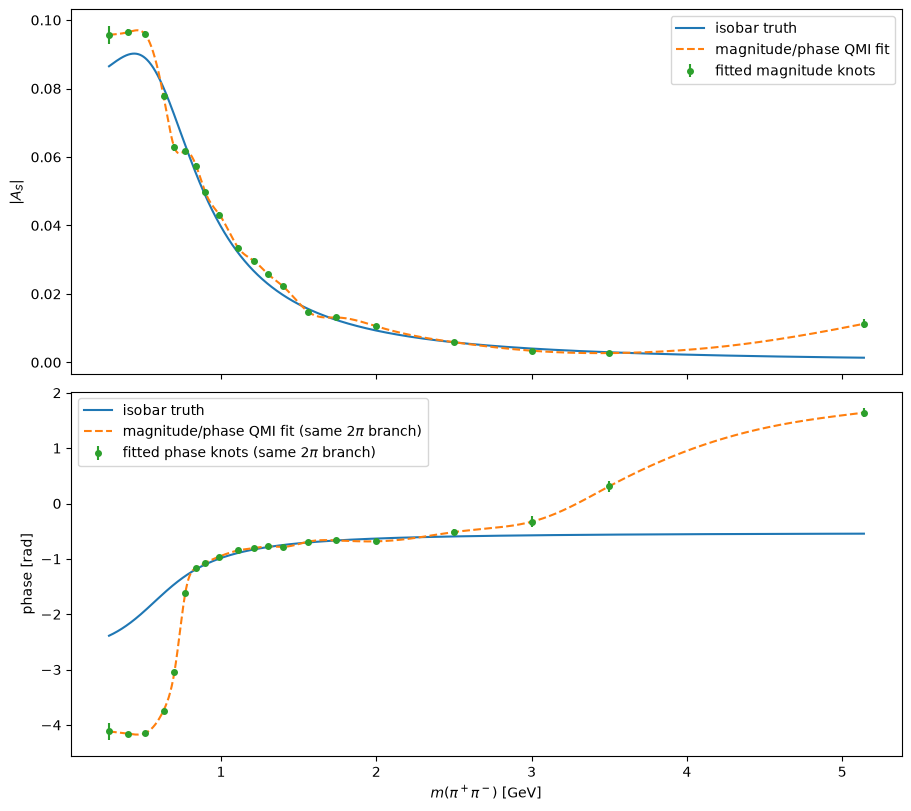

post-fit relative complex RMS = 1.469007e+00
wrapped phase-difference RMS  = 1.197097e+00 rad
max |wrapped phase difference| = 2.241531e+00 rad


In [10]:
def resolved_qmi(qmi_model, values):
    return QMI(
        knots=qmi_model.knots,
        magnitudes=tuple(
            float(parameter.resolve(values))
            if hasattr(parameter, "resolve") else float(parameter)
            for parameter in qmi_model.magnitudes
        ),
        phases=tuple(
            float(parameter.resolve(values))
            if hasattr(parameter, "resolve") else float(parameter)
            for parameter in qmi_model.phases
        ),
        interpolation=qmi_model.interpolation,
    )


def fitted_qmi_single_pair(masses, values):
    comp = component_by_name(fit_model, "S_QMI")
    context = comp.function.context.resolve(values)
    dynamics = np.asarray(
        resolved_qmi(qmi, values)(jnp.asarray(masses), context)
    )
    coefficient = complex(np.asarray(comp.coefficient.value(values)))
    scale = float(np.asarray(fit_model._component_scale(comp, values)))
    return coefficient * scale * dynamics


fit_scan = fitted_qmi_single_pair(mass_scan, fit_values)

fit_knot_magnitudes = np.asarray(
    [float(parameter.resolve(fit_values)) for parameter in qmi_magnitudes]
)
fit_knot_phases_raw = np.asarray(
    [float(parameter.resolve(fit_values)) for parameter in qmi_phases]
)
fit_knot_magnitude_errors = np.asarray(
    [float(result.errors[parameter.name]) for parameter in qmi_magnitudes]
)
fit_knot_phase_errors = np.asarray(
    [float(result.errors[parameter.name]) for parameter in qmi_phases]
)
fit_knot_amplitudes = fit_knot_magnitudes * np.exp(1j * fit_knot_phases_raw)

# Compare phases on the physical branch closest to the unwrapped truth.
truth_phase = np.unwrap(np.angle(truth_scan))
phase_difference = np.angle(fit_scan * np.conj(truth_scan))
fit_phase_aligned = truth_phase + phase_difference

knot_phase_difference = np.angle(
    np.exp(1j * (fit_knot_phases_raw - truth_knot_phases))
)
aligned_knot_phases = truth_knot_phases + knot_phase_difference

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, constrained_layout=True)

axes[0].plot(mass_scan, np.abs(truth_scan), label="isobar truth")
axes[0].plot(mass_scan, np.abs(fit_scan), "--", label="magnitude/phase QMI fit")
axes[0].errorbar(
    QMI_KNOTS,
    fit_knot_magnitudes,
    yerr=fit_knot_magnitude_errors,
    fmt="o",
    markersize=4,
    label="fitted magnitude knots",
)
axes[0].set_ylabel(r"$|A_S|$")
axes[0].legend()

axes[1].plot(mass_scan, truth_phase, label="isobar truth")
axes[1].plot(
    mass_scan,
    fit_phase_aligned,
    "--",
    label=r"magnitude/phase QMI fit (same $2\pi$ branch)",
)
axes[1].errorbar(
    QMI_KNOTS,
    aligned_knot_phases,
    yerr=fit_knot_phase_errors,
    fmt="o",
    markersize=4,
    label=r"fitted phase knots (same $2\pi$ branch)",
)
axes[1].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
axes[1].set_ylabel("phase [rad]")
axes[1].legend()

plt.show()

complex_rms = np.sqrt(
    np.mean(np.abs(fit_scan - truth_scan)**2)
    / np.mean(np.abs(truth_scan)**2)
)
phase_rms = np.sqrt(np.mean(phase_difference**2))
phase_max = np.max(np.abs(phase_difference))

print(f"post-fit relative complex RMS = {complex_rms:.6e}")
print(f"wrapped phase-difference RMS  = {phase_rms:.6e} rad")
print(f"max |wrapped phase difference| = {phase_max:.6e} rad")


## Knot-by-knot closure

Magnitude and phase are reported directly because they are the fitted QMI
coordinates in this notebook.

For the phase pull we use the wrapped difference

[
\Delta\phi_i
=
\arg\left[e^{i(\phi_i^{\rm fit}-\phi_i^{\rm truth})}\right],
]

so a physically equivalent (2pi) branch does not create an artificial large
pull. The raw fitted phase is also retained in the table for diagnosing branch
changes during the minimization.


In [11]:
rows = []
for i, (
    mass,
    magnitude_parameter,
    phase_parameter,
    magnitude_truth,
    phase_truth,
) in enumerate(
    zip(
        QMI_KNOTS,
        qmi_magnitudes,
        qmi_phases,
        truth_knot_magnitudes,
        truth_knot_phases,
    )
):
    magnitude_fit = float(magnitude_parameter.resolve(fit_values))
    phase_fit_raw = float(phase_parameter.resolve(fit_values))
    magnitude_error = float(result.errors[magnitude_parameter.name])
    phase_error = float(result.errors[phase_parameter.name])

    phase_difference_knot = np.angle(
        np.exp(1j * (phase_fit_raw - phase_truth))
    )
    phase_fit_aligned = phase_truth + phase_difference_knot

    rows.append({
        "knot": i,
        "m [GeV]": mass,
        "mag truth": magnitude_truth,
        "mag fit": magnitude_fit,
        "mag err": magnitude_error,
        "mag pull": (
            (magnitude_fit - magnitude_truth) / magnitude_error
            if magnitude_error > 0.0 else np.nan
        ),
        "phase truth": phase_truth,
        "phase fit raw": phase_fit_raw,
        "phase fit aligned": phase_fit_aligned,
        "phase err": phase_error,
        "phase pull": (
            phase_difference_knot / phase_error
            if phase_error > 0.0 else np.nan
        ),
    })

qmi_table = pd.DataFrame(rows)
display(qmi_table)


,knot,m [GeV],mag truth,mag fit,mag err,mag pull,phase truth,phase fit raw,phase fit aligned,phase err,phase pull
0,0,0.279141,0.086494,0.095676,0.002605,3.524415,-2.388076,-4.116616,-4.116616,0.153091,-11.290936
1,1,0.400000,0.089854,0.096430,0.000932,7.058410,-2.187776,-4.158066,-4.158066,0.035257,-55.883475
2,2,0.510000,0.088972,0.095917,0.000864,8.041607,-1.935516,-4.149071,-4.149071,0.018442,-120.028755
3,3,0.630000,0.080232,0.077788,0.000958,-2.550891,-1.626025,-3.739382,-3.739382,0.013268,-159.277752
4,4,0.700000,0.072161,0.062775,0.001032,-9.093556,-1.457106,-3.048395,-3.048395,0.018616,-85.479014
5,5,0.770000,0.063429,0.061699,0.000730,-2.370442,-1.309673,-1.619672,-1.619672,0.033010,-9.391003
6,6,0.840000,0.055075,0.057411,0.000846,2.759423,-1.186568,-1.164746,-1.164746,0.023000,0.948762
7,7,0.900000,0.048635,0.049626,0.000759,1.305836,-1.099237,-1.072312,-1.072312,0.018283,1.472680
8,8,0.990000,0.040443,0.043154,0.000668,4.057631,-0.994694,-0.957159,-0.957159,0.016959,2.213268
9,9,1.110000,0.032025,0.033537,0.000674,2.244327,-0.892718,-0.847950,-0.847950,0.020231,2.212855


## Higher-wave closure

These plots also use the absolute fitted normalization. There is **no**
`truth.sum()/fit.sum()` rescaling.


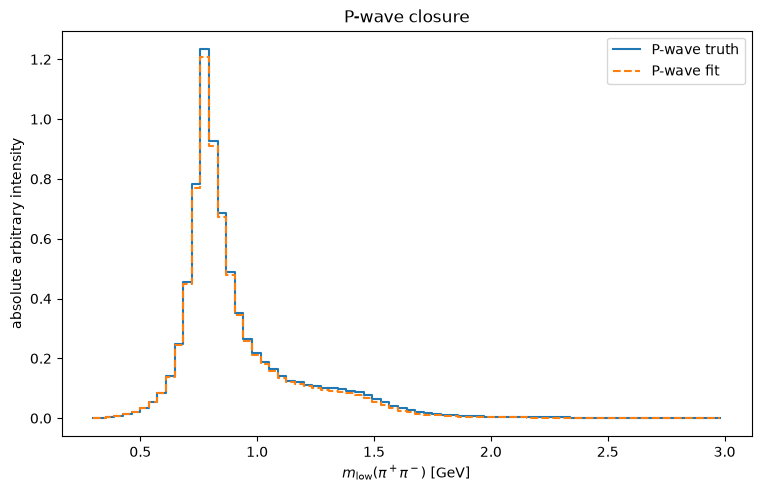

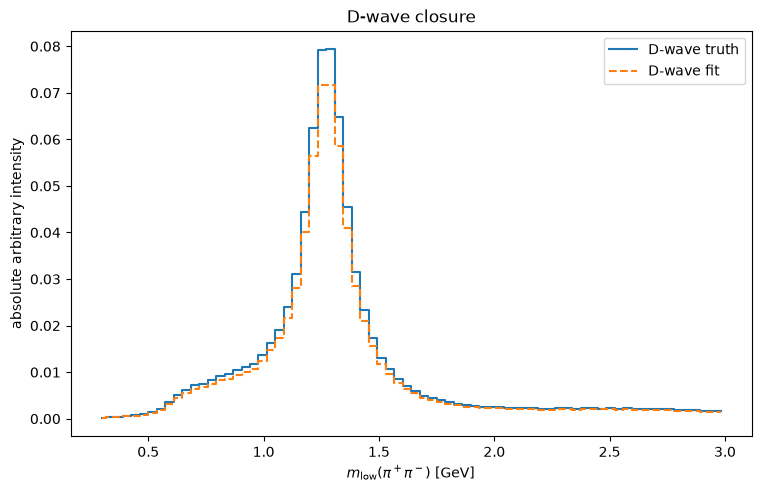

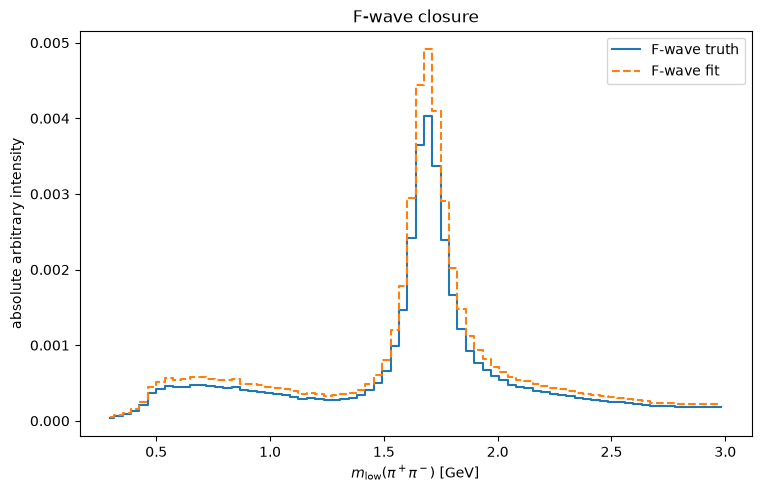

In [12]:
def component_amplitude(model, name, data, values):
    comp = component_by_name(model, name)
    dynamics = jnp.asarray(comp.function(data, values))
    coefficient = jnp.asarray(comp.coefficient.value(values))
    scale = model._component_scale(comp, values)
    return coefficient * scale * dynamics


def coherent_group(model, names, data, values):
    total = 0.0j
    for name in names:
        total = total + component_amplitude(model, name, data, values)
    return jnp.asarray(total)


WAVES = {
    "P": ("rho770", "omega782", "rho1450"),
    "D": ("f2_1270",),
    "F": ("rho3_1690",),
}

validation = generator.generate_phase_space(700_000, seed=SEED + 501)

def min_pipi_mass(sample):
    return np.sqrt(
        np.minimum(np.asarray(sample.s13), np.asarray(sample.s23))
    )

def binned_wave_intensity(sample, generator_model, fitted_model, names, fit_values, bins):
    data = sample.as_dict()
    truth_amp = np.asarray(coherent_group(generator_model, names, data, {}))
    fit_amp = np.asarray(coherent_group(fitted_model, names, data, fit_values))
    mass = min_pipi_mass(sample)
    weights = np.asarray(sample.weights)
    truth_hist, edges = np.histogram(
        mass, bins=bins, weights=weights*np.abs(truth_amp)**2
    )
    fit_hist, _ = np.histogram(
        mass, bins=edges, weights=weights*np.abs(fit_amp)**2
    )
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers, truth_hist, fit_hist

bins = np.linspace(2*M_PI, 3.0, 75)

for wave, names in WAVES.items():
    centers, truth_hist, fit_hist = binned_wave_intensity(
        validation, generator, fit_model, names, fit_values, bins
    )
    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    ax.step(centers, truth_hist, where="mid", label=f"{wave}-wave truth")
    ax.step(centers, fit_hist, where="mid", linestyle="--", label=f"{wave}-wave fit")
    ax.set_xlabel(r"$m_{\rm low}(\pi^+\pi^-)$ [GeV]")
    ax.set_ylabel("absolute arbitrary intensity")
    ax.set_title(f"{wave}-wave closure")
    ax.legend()
    plt.show()


## Higher-wave coefficient pulls


In [13]:
rows = []
for name in ("rho770", "omega782", "rho1450", "f2_1270", "rho3_1690"):
    truth = TRUTH_COEFFICIENTS[name]
    for field in ("x", "y"):
        pname = f"{name}.{field}"
        parameter = next(
            (p for p in session.parameters if p.name == pname),
            None,
        )
        if parameter is None:
            continue
        fitted = fit_values[pname]
        error = 0.0 if parameter.fixed else float(result.errors[pname])
        pull = (
            np.nan
            if error == 0.0
            else (fitted - truth[field]) / error
        )
        rows.append({
            "component": name,
            "parameter": field,
            "truth": truth[field],
            "fit": fitted,
            "error": error,
            "pull": pull,
            "fixed": parameter.fixed,
        })

coefficient_table = pd.DataFrame(rows)
display(coefficient_table)


,component,parameter,truth,fit,error,pull,fixed
0,rho770,x,1.000,1.000000,0.000000,NaN,True
1,rho770,y,0.000,0.000000,0.000000,NaN,True
2,omega782,x,0.091,0.089803,0.002142,-0.558954,False
3,omega782,y,-0.007,-0.008474,0.002362,-0.623852,False
4,rho1450,x,-0.223,-0.255632,0.004995,-6.533417,False
5,rho1450,y,0.191,0.141822,0.005460,-9.007015,False
6,f2_1270,x,0.291,0.248263,0.004152,-10.293281,False
7,f2_1270,y,0.204,0.229158,0.003752,6.704701,False
8,rho3_1690,x,0.073,0.092543,0.002836,6.890383,False
9,rho3_1690,y,-0.045,-0.019798,0.004044,6.231338,False


## Fit projections


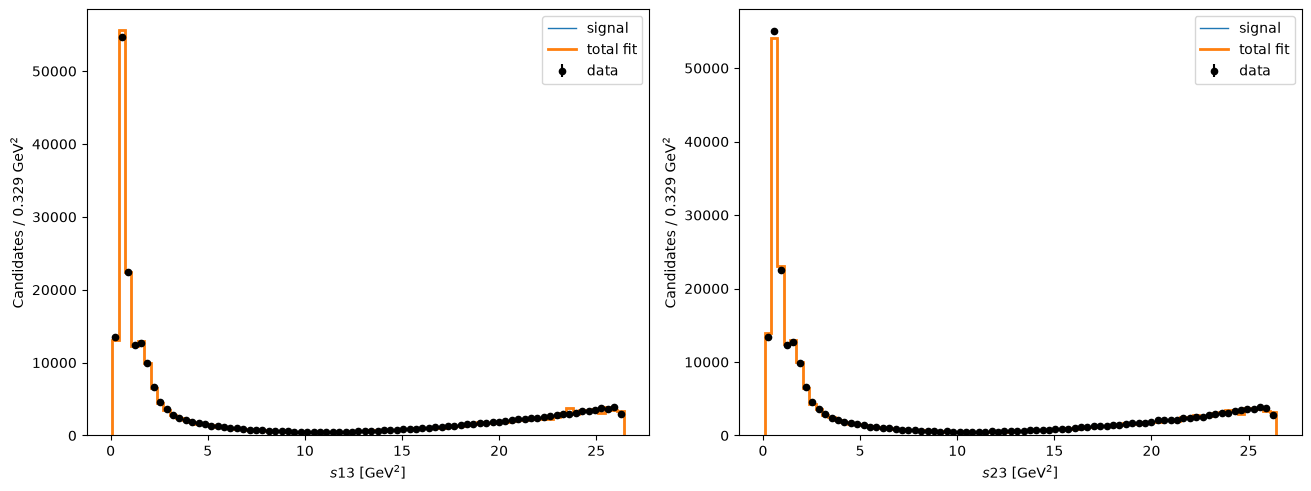

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

session.plot_projection(
    result,
    "s13",
    bins=80,
    projection_size=300_000,
    projection_seed=SEED + 700,
    ax=axes[0],
)
session.plot_projection(
    result,
    "s23",
    bins=80,
    projection_size=300_000,
    projection_seed=SEED + 701,
    ax=axes[1],
)

plt.show()


## Optional diagnostics if the baseline closure fails

Run these if the direct S-wave closure is poor.

The first check compares the JAX gradient used by Minuit with a finite-difference
gradient at the flat polar QMI starting point, (|A_i|=1), (phi_i=0).
The second evaluates the NLL at the start and at the fitted point.


In [15]:
# Uncomment if needed:
#
gradient_check = session.minimizer(
    tolerance=1e-4,
    verbose=1,
).check_gradient(
    start_values,
    step_scale=1e-5,
    print_table=True,
)

print("NLL(start) =", float(session.objective(start_values)))
print("NLL(fit)   =", float(session.objective(fit_values)))


parameter                     JAX    finite diff      abs err      rel err
omega782.x           4.324488e+02   4.324488e+02    1.817e-05    4.201e-08
omega782.y          -3.783144e+03  -3.783144e+03    5.254e-06    1.389e-09
f2_1270.x           -8.004424e+02  -8.004424e+02    6.629e-06    8.281e-09
f2_1270.y            6.669623e+03   6.669623e+03    2.956e-06    4.433e-10
rho1450.x            2.810955e+03   2.810955e+03    9.378e-06    3.336e-09
rho1450.y            4.536060e+03   4.536060e+03    6.296e-06    1.388e-09
rho3_1690.x          6.383599e+02   6.383599e+02    2.361e-06    3.699e-09
rho3_1690.y          2.217298e+03   2.217298e+03    5.520e-06    2.490e-09
S_QMI.magnitude[0]  -7.122714e+02  -7.122713e+02    4.427e-06    6.216e-09
S_QMI.magnitude[1]  -3.292533e+03  -3.292533e+03    2.959e-06    8.987e-10
S_QMI.magnitude[2]  -7.659796e+03  -7.659796e+03    9.619e-06    1.256e-09
S_QMI.magnitude[3]  -1.090733e+04  -1.090733e+04    1.271e-05    1.165e-09
S_QMI.magnitude[4]  -2.03

## Interpretation

For this polar baseline test, a successful closure means:

1. the representation-only magnitude/phase QMI follows the (sigma) truth closely;
2. the post-fit physical QMI magnitude and phase remain on the truth without
   arbitrary rescaling or phase shifting;
3. the fitted magnitude and wrapped phase pulls are statistically compatible
   with the generated truth;
4. higher-wave coefficients stay statistically compatible with their generated values;
5. P/D/F-wave shapes and absolute intensities close;
6. the fitted event projections describe the generated toy.

This baseline deliberately starts away from truth: every magnitude starts at
(1) and every phase at (0). Unlike the Cartesian notebook, magnitude and
phase here are the actual minimizer coordinates.
